# Skenario A - Custom CNN Baseline (Tanpa Augmentasi)
**Proyek Skripsi:** Klasifikasi Jenis Obat Tablet Menggunakan Convolutional Neural Network (CNN)

## Tujuan Notebook Ini:
1. Memuat dataset yang telah distandarisasi dari direktori `baseline_dataset`.
2. Membangun arsitektur Custom CNN (3 lapis konvolusi) sebagai model *baseline*.
3. Melatih model murni menggunakan data asli (tanpa teknik *Data Augmentation*).
4. Mengevaluasi performa model menggunakan data uji (*test set*).
5. Menghasilkan artefak evaluasi (*Learning Curves*, *Confusion Matrix*, *Classification Report*) untuk Bab IV Skripsi.

In [1]:
# Import library yang dibutuhkan
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

# 1. Hubungkan Google Drive
drive.mount('/content/drive')

print("✅ Library berhasil diimpor dan Google Drive terhubung.")

Mounted at /content/drive
✅ Library berhasil diimpor dan Google Drive terhubung.


## 1. Konfigurasi Parameter & Persiapan Data
Mengatur direktori input dari hasil preprocessing sebelumnya dan menyiapkan `ImageDataGenerator`.
Pada skenario A, `ImageDataGenerator` **hanya** digunakan untuk melakukan normalisasi piksel (membagi nilai RGB dengan 255). Tidak ada parameter augmentasi geometris yang dimasukkan.

In [2]:
# ==========================================
# KONFIGURASI DIREKTORI & HYPERPARAMETER
# ==========================================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB'
BASELINE_DIR = os.path.join(BASE_DIR, 'data', 'baseline_dataset')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs', 'scenario_a')

# Buat folder output khusus Skenario A jika belum ada
os.makedirs(OUTPUTS_DIR, exist_ok=True)

TARGET_CLASSES = [
    "cataflam_50_mg", "cetirizin_10_mg", "pantoprazol_sandoz_40_mg",
    "c_vitamin_teva_500_mg", "aspirin_ultra_500_mg",
    "algoflex_forte_dolo_400_mg", "merckformin_xr_1000_mg"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # Menggunakan 16 untuk mencegah Out of Memory dan menjaga stabilitas gradien pada data kecil
EPOCHS = 50 # Nilai maksimal, akan dikontrol oleh Early Stopping

def create_data_generators():
    """
    Membuat data generator untuk memuat citra ke dalam memori secara bertahap (batch).
    Hanya melakukan rescaling (Normalisasi 0-1) tanpa augmentasi spasial.

    Returns:
        train_gen, val_gen, test_gen: Generator Keras untuk masing-masing split.
    """
    # Inisialisasi generator (Hanya normalisasi piksel)
    datagen = ImageDataGenerator(rescale=1.0/255.0)

    print("Memuat Data Latih (Train)...")
    train_gen = datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'train'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=True
    )

    print("Memuat Data Validasi (Validation)...")
    val_gen = datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'valid'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=False
    )

    print("Memuat Data Uji (Test)...")
    test_gen = datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'test'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=False # Shuffle False sangat penting untuk perhitungan Confusion Matrix yang akurat
    )

    return train_gen, val_gen, test_gen

# Eksekusi pembuatan generator
train_generator, val_generator, test_generator = create_data_generators()

Memuat Data Latih (Train)...
Found 196 images belonging to 7 classes.
Memuat Data Validasi (Validation)...
Found 42 images belonging to 7 classes.
Memuat Data Uji (Test)...
Found 42 images belonging to 7 classes.


## 2. Perancangan Arsitektur Custom CNN (Baseline)
Membangun model CNN mandiri dengan kedalaman menengah. Arsitektur ini menggunakan:
- 3 Blok Ekstraksi Fitur (`Conv2D` + `MaxPooling2D`).
- Aktivasi `ReLU` untuk menghindari masalah *vanishing gradient*.
- `Flatten` untuk mengubah matriks fitur menjadi vektor 1D.
- `Dropout` (0.5) untuk teknik regularisasi dasar.
- `Dense` layer dengan fungsi aktivasi `Softmax` untuk menghasilkan probabilitas 7 kelas.

In [3]:
def build_custom_cnn_baseline(input_shape=(224, 224, 3), num_classes=7):
    """
    Membangun arsitektur Custom CNN untuk Skenario Baseline.

    Args:
        input_shape (tuple): Dimensi input citra (default: 224x224x3).
        num_classes (int): Jumlah kategori klasifikasi.

    Returns:
        keras.Model: Model kompilasi CNN yang siap dilatih.
    """
    model = Sequential([
        # Block 1: Ekstraksi fitur tingkat rendah (tepi, garis)
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 2: Ekstraksi fitur tingkat menengah (bentuk dasar obat)
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 3: Ekstraksi fitur tingkat tinggi (pola kompleks/imprint)
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        # Tahap Klasifikasi
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Regularisasi untuk mematikan 50% neuron secara acak
        Dense(num_classes, activation='softmax')
    ])

    # Optimizer Adam (dinamis) dan fungsi Loss untuk klasifikasi > 2 kelas
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Inisialisasi model
model_a = build_custom_cnn_baseline(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=len(TARGET_CLASSES))
model_a.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Proses Training Skenario A
Melatih model dengan konfigurasi pengaman tingkat tinggi:
- **ModelCheckpoint:** Hanya menyimpan bobot model pada titik *epoch* di mana `val_accuracy` (akurasi validasi) mencapai nilai tertinggi.
- **EarlyStopping:** Menghentikan iterasi secara otomatis jika nilai `val_loss` tidak mengalami perbaikan selama 10 *epoch* berturut-turut. Ini adalah justifikasi ilmiah mengapa parameter `epochs=50` sangat aman digunakan.

In [4]:
# Mendefinisikan path penyimpanan fisik model
MODEL_SAVE_PATH = os.path.join(MODELS_DIR, 'scenario_a.h5')

def train_model(model, train_gen, val_gen):
    """
    Mengeksekusi proses pelatihan (training) model beserta callbacks.
    """
    # 1. Setup Callbacks
    checkpoint = ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10, # Toleransi 10 epoch tanpa perbaikan
        restore_best_weights=True,
        verbose=1
    )

    print("\n🚀 Memulai Proses Pelatihan Skenario A (Baseline)...")
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

    return history

# Eksekusi Training
history_a = train_model(model_a, train_generator, val_generator)


🚀 Memulai Proses Pelatihan Skenario A (Baseline)...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1380 - loss: 2.6279
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_a.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_a.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 96s 7s/step - accuracy: 0.1429 - loss: 2.2960 - val_accuracy: 0.1429 - val_loss: 1.9653
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1190 - loss: 1.9575 
Epoch 2: val_accuracy improved from 0.14286 to 0.26190, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_a.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_a.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.0918 - loss: 1.9658 - val_accuracy: 0.2619 - val_loss: 1.9460
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.1675 - loss: 1.9459
Epoch 3: val_accuracy did not improve from 0.26190
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.1531 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1088 - loss: 1.9458
Epoch 4: val_accuracy did not improve from 0.26190
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.1327 - loss: 1.9459 - val_accuracy: 0.1429 - val_loss: 1.9452
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1619 - loss: 1.9460
Epoch 5: val_accuracy did not improve from 0.26190
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.1429 - loss: 1.9456 - val_accuracy: 0.1667 - val_loss: 1.9430
Epoch 6/50



Epoch 8: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_a.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.2296 - loss: 1.8704 - val_accuracy: 0.3333 - val_loss: 1.8219
Epoch 9/50
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2701 - loss: 1.7910
Epoch 9: val_accuracy improved from 0.33333 to 0.40476, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_a.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_a.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.2398 - loss: 1.7614 - val_accuracy: 0.4048 - val_loss: 1.6772
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3250 - loss: 1.5813
Epoch 10: val_accuracy did not improve from 0.40476
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3112 - loss: 1.5688 - val_accuracy: 0.2143 - val_loss: 1.7449
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2836 - loss: 1.4965
Epoch 11: val_accuracy did not improve from 0.40476
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.3265 - loss: 1.4483 - val_accuracy: 0.3571 - val_loss: 1.5738
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3951 - loss: 1.2866
Epoch 12: val_accuracy did not improve from 0.40476
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.4082 - loss: 1.3013 - val_accuracy: 0.3571 - val_loss: 1.6507
Epoch 1

## 4. Evaluasi & Visualisasi Hasil Training (Learning Curves)
Membuat plot grafis dari riwayat *Training Accuracy vs Validation Accuracy* serta *Loss*. Grafik ini adalah lampiran wajib untuk Bab IV guna menganalisis apakah model mengalami *underfitting*, *optimal*, atau *overfitting*.

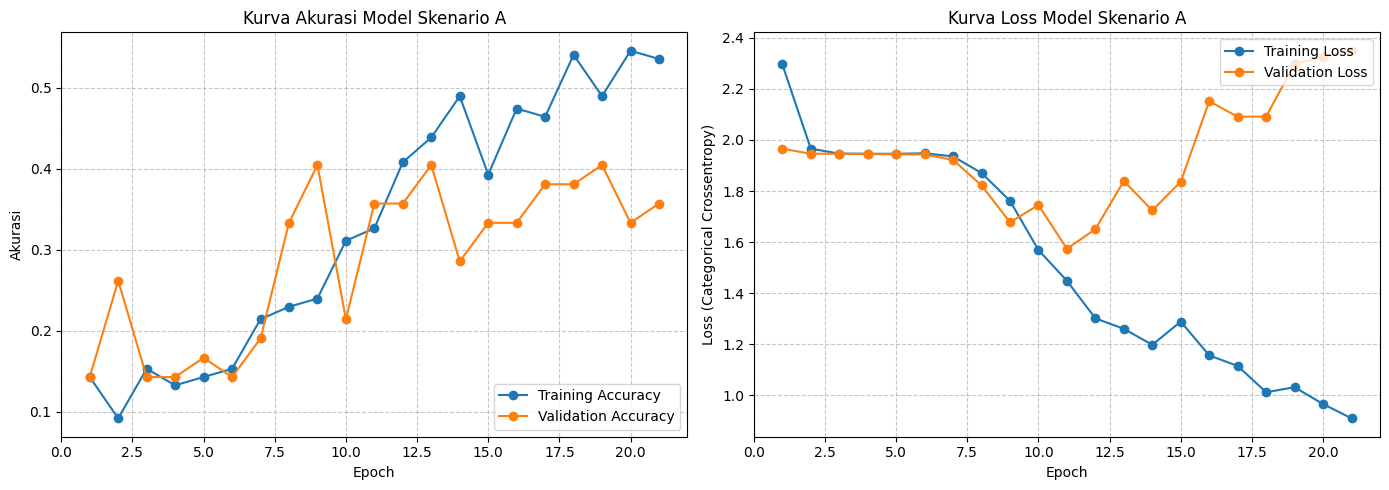

In [5]:
def plot_learning_curves(history, save_dir):
    """
    Menghasilkan dan menyimpan grafik metrik evaluasi per epoch.

    Args:
        history (keras.callbacks.History): Objek riwayat pelatihan Keras.
        save_dir (str): Direktori penyimpanan gambar output.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Kurva Akurasi Model Skenario A')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Kurva Loss Model Skenario A')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Categorical Crossentropy)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    # Simpan artefak
    plt.savefig(os.path.join(save_dir, 'scenario_a_learning_curves.png'), dpi=300)
    plt.show()

plot_learning_curves(history_a, OUTPUTS_DIR)

## 5. Pengujian Kinerja Akhir (Testing)
Menguji model terbaik (hasil dari *checkpoint*) menggunakan `test_generator` yang memuat gambar-gambar murni yang sama sekali belum pernah "dilihat" oleh model.
Tahap ini menghasilkan matriks evaluasi final berupa *Confusion Matrix* dan *Classification Report* (Precision, Recall, F1-Score).


🔍 Memuat Model Terbaik dan Mengevaluasi Data Uji...


✅ Akurasi Uji Global (Test Accuracy): 26.19%
✅ Nilai Loss Uji (Test Loss): 1.7730

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step

--- CLASSIFICATION REPORT ---
                            precision    recall  f1-score   support

            cataflam_50_mg       0.33      0.33      0.33         6
           cetirizin_10_mg       0.00      0.00      0.00         6
  pantoprazol_sandoz_40_mg       0.00      0.00      0.00         6
     c_vitamin_teva_500_mg       1.00      0.17      0.29         6
      aspirin_ultra_500_mg       0.00      0.00      0.00         6
algoflex_forte_dolo_400_mg       0.20      0.33      0.25         6
    merckformin_xr_1000_mg       0.24      1.00      0.39         6

                  accuracy                           0.26        42
                 macro avg       0.25      0.26      0.18        42
              weighted avg       0.25      0.26      0.18        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


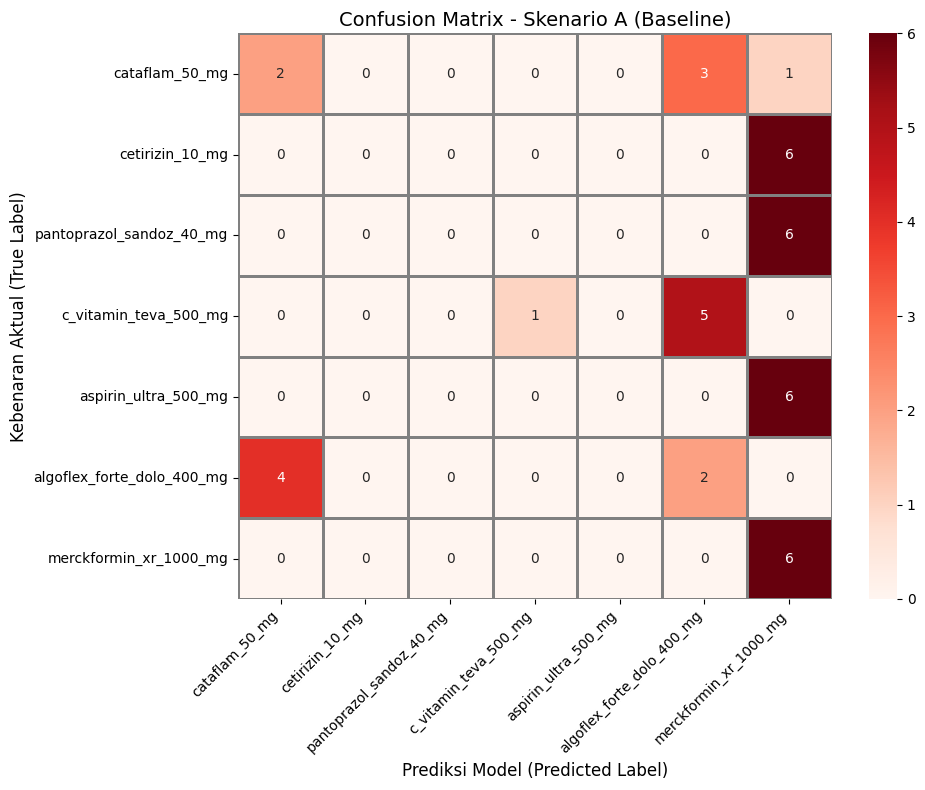

In [6]:
def evaluate_model_on_test(model_path, test_gen, classes, save_dir):
    """
    Melakukan evaluasi prediksi pada data uji dan membuat metrik confusion matrix.

    Args:
        model_path (str): Lokasi file .h5 terbaik dari pelatihan.
        test_gen (ImageDataGenerator): Generator data uji.
        classes (list): Daftar nama kelas.
        save_dir (str): Lokasi penyimpanan artefak grafik.
    """
    print("\n🔍 Memuat Model Terbaik dan Mengevaluasi Data Uji...")
    best_model = tf.keras.models.load_model(model_path)

    # Evaluasi global (Loss & Accuracy)
    test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
    print(f"✅ Akurasi Uji Global (Test Accuracy): {test_acc * 100:.2f}%")
    print(f"✅ Nilai Loss Uji (Test Loss): {test_loss:.4f}\n")

    # Melakukan prediksi terhadap semua data di generator test
    test_gen.reset() # Reset generator sebelum prediksi untuk urutan yang akurat
    predictions = best_model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes

    # 1. Classification Report
    report = classification_report(true_classes, predicted_classes, target_names=classes)
    print("\n--- CLASSIFICATION REPORT ---")
    print(report)

    # Simpan report ke text file
    with open(os.path.join(save_dir, 'scenario_a_classification_report.txt'), 'w') as f:
        f.write(report)

    # 2. Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=classes, yticklabels=classes,
                linewidths=1, linecolor='gray')

    plt.title('Confusion Matrix - Skenario A (Baseline)', fontsize=14)
    plt.xlabel('Prediksi Model (Predicted Label)', fontsize=12)
    plt.ylabel('Kebenaran Aktual (True Label)', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'scenario_a_confusion_matrix.png'), dpi=300)
    plt.show()

# Eksekusi evaluasi akhir
evaluate_model_on_test(MODEL_SAVE_PATH, test_generator, TARGET_CLASSES, OUTPUTS_DIR)

## ✅ KESIMPULAN FASE 3 (Skenario A)
Eksperimen *baseline* telah berhasil dijalankan. Artefak berupa `scenario_a.h5`, kurva pembelajaran, matriks kebingungan (*confusion matrix*), dan laporan klasifikasi telah disimpan dengan aman di Google Drive Anda.

**Observasi untuk Skripsi:**
Jika nilai Akurasi Data Latih (*Train Acc*) sangat tinggi mendekati 100%, sementara Akurasi Uji (*Test Acc*) dan Akurasi Validasi jauh di bawahnya (misal 50%), maka model secara empiris terbukti mengalami **Overfitting**. Ini membuktikan hipotesis bahwa data asli yang minim (28 citra latih per kelas) tidak cukup kuat untuk dilatih dari awal tanpa teknik khusus.

*Anda kini siap melanjutkan eksperimen ke Notebook `03_Scenario_B.ipynb`.*